In [40]:
# Import

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

In [42]:
# Loading the datasets

In [43]:
df = pd.read_excel("Telco_customer_churn.xlsx")
print(df.shape)
print(df.head())

(7043, 33)
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly C

In [44]:
# EDA

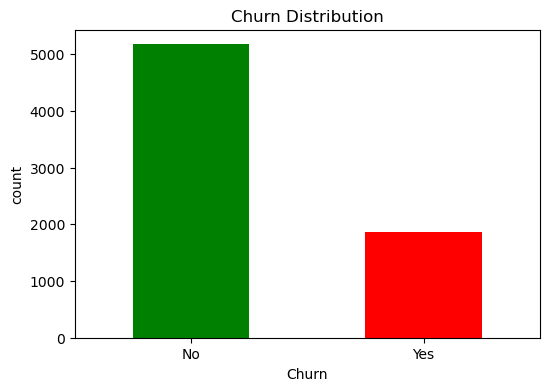

In [45]:
plt.figure(figsize=(6,4))
df['Churn Label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.show()

In [46]:
# Checking missing values

In [47]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Churn Reason    5174
dtype: int64


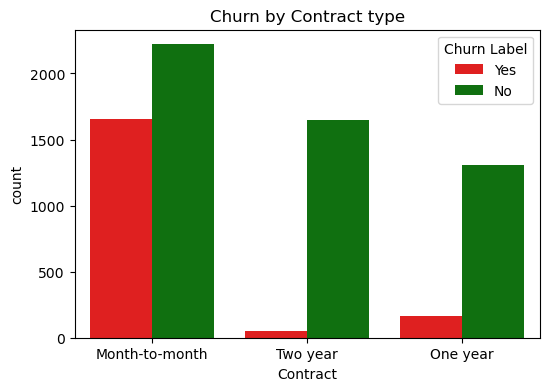

In [48]:
# Churn by contract type

plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn Label', data=df, palette=['red', 'green'])
plt.title('Churn by Contract type')
plt.show()

C:\Users\Landl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


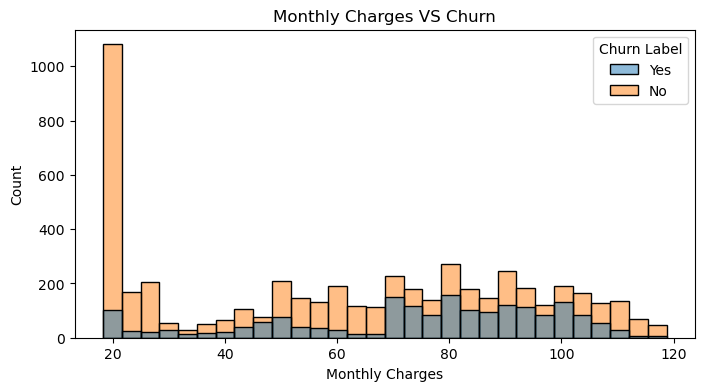

In [50]:
# Churn by Charges Distribution

plt.figure(figsize=(8,4))
sns.histplot(x='Monthly Charges', hue='Churn Label', data=df, bins=30)
plt.title('Monthly Charges VS Churn')
plt.show()

In [51]:
# Drop Unnecessary columns

cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Reason', 'Churn Score', 
                'CLTV', 'Churn Value']
df.drop(cols_to_drop, axis=1, inplace=True)
print(df.shape)

(7043, 20)


In [52]:
print(df.select_dtypes(include='object').columns)
print(df.dtypes)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Total Charges', 'Churn Label'],
      dtype='object')
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
dtype: object


In [54]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

In [55]:
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [56]:
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
            'Payment Method'] 
df = pd.get_dummies(df, columns=cat_cols)
print('After Encoding:', df.shape)

After Encoding: (7043, 119)


In [58]:
X = df.drop('Churn Label', axis=1)
y= df['Churn Label']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (5634, 118) Test: (1409, 118)


In [60]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print('\n Logisctic Regression Accuracy:', accuracy_score(y_test, lr_pred))


 Logisctic Regression Accuracy: 0.808374733853797


In [61]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=23)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print('\n Random Forest Classifier Accuracy:', accuracy_score(y_test, rf_pred))


 Random Forest Classifier Accuracy: 0.8062455642299503


In [62]:
print('\n Random Forest Classifier Report:')
print(classification_report(y_test, rf_pred))


 Random Forest Classifier Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      1044
           1       0.68      0.47      0.56       365

    accuracy                           0.81      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.81      0.79      1409



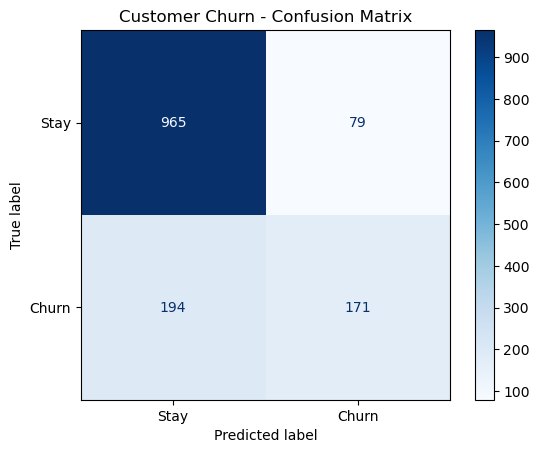

In [64]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Customer Churn - Confusion Matrix')
plt.show()